In [24]:
# %pip install pandas scikit-learn datasets transformers numpy torch

In [25]:
# %pip install 'accelerate>=1.1.0' -q

In [26]:
# %pip install matplotlib

In [27]:
import pandas as pd

from sklearn.model_selection import train_test_split

# 1. Load data (Giả sử file của bạn là data.csv, cột 'text' và 'label')
df = pd.read_csv('/kaggle/input/datasets/hngkininh/final-comment-data/final_segment_data.csv')


train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_id'])

df.head(5)

,comment,label_id
0,nhiều cty ở trong dồng nai không nhận người ở ...,0.0
1,"nghệ_an vốn là nơi đất hc , h chặn luôn ước_mơ...",0.0
2,xưa thời cty nó không dám nhận nghệ_an thanh_h...,0.0
3,"luôn tự_hào về người quảng_bình yêu _ thương ,...",0.0
4,"ê nha ê nha ê nha nũng _ nịu , đừng chửi người...",0.0


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer




# --- BƯỚC 1: CHIA DỮ LIỆU (TRAIN - VAL - TEST) ---
# Chia Test 10% trước
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.1, 
    random_state=42, 
    stratify=df['label_id'] # Đảm bảo tỷ lệ Clean/Offensive/Hate đồng đều
)

# Chia tiếp phần còn lại thành Train (85%) và Val (15%)
train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=train_val_df['label_id']
)

# --- BƯỚC 2: CHUẨN BỊ DATASET ---
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def prepare_dataset(df):
    df = df.copy()
    df['label_id'] = df['label_id'].astype('int64')
    df = df.reset_index(drop=True)
    
    dataset = Dataset.from_pandas(df)
    
    def tokenize_function(examples):
        return tokenizer(examples["comment"], padding="max_length", truncation=True, max_length=128)
    
    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.rename_column("label_id", "labels")
    dataset = dataset.remove_columns(["comment"])
    dataset.set_format("torch")
    return dataset

# Tạo 3 bộ dataset chuẩn
train_dataset = prepare_dataset(train_df)
val_dataset = prepare_dataset(val_df)
test_dataset = prepare_dataset(test_df)

print(f"Cấu trúc: {train_dataset.column_names}")
print(f"Số lượng: Train({len(train_dataset)}) - Val({len(val_dataset)}) - Test({len(test_dataset)})")

Map:   0%|          | 0/7003 [00:00<?, ? examples/s]

Map:   0%|          | 0/1236 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Cấu trúc: ['labels', 'input_ids', 'attention_mask']
Số lượng: Train(7003) - Val(1236) - Test(916)


In [29]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification

# Khởi tạo model với 3 nhãn
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, problem_type="single_label_classification")

# Định nghĩa hàm tính toán các chỉ số khi Validation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # Dùng weighted F1 vì dữ liệu của bạn có thể bị mất cân bằng (CLEAN nhiều hơn HATE)
    f1 = f1_score(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    
    return {"accuracy": acc, "f1": f1}

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
# Đóng băng toàn bộ phần encoder của PhoBERT
from transformers import TrainingArguments, Trainer

for param in model.roberta.parameters():
    param.requires_grad = False

# Tính toán số bước warmup thủ công để chắc chắn tương thích mọi phiên bản
total_steps_s1 = (len(train_dataset) // 16) * 3 # Giả sử train 3 epoch, batch 16

args_stage1 = TrainingArguments(
    output_dir="./results_stage1",
    num_train_epochs=3,
    learning_rate=2e-4,            # LR cao hơn vì chỉ train lớp classifier
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    warmup_steps=int(0.1 * total_steps_s1), # 10% số bước đầu để khởi động
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer_s1 = Trainer(
    model=model,
    args=args_stage1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("--- BẮT ĐẦU GIAI ĐOẠN 1: HUẤN LUYỆN CLASSIFIER ---")
trainer_s1.train()

--- BẮT ĐẦU GIAI ĐOẠN 1: HUẤN LUYỆN CLASSIFIER ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.812529,0.869741,0.865511
2,No log,0.763409,0.881068,0.879073
3,1.020027,0.740711,0.887540,0.885126


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=657, training_loss=0.9567881544975385, metrics={'train_runtime': 166.6606, 'train_samples_per_second': 126.059, 'train_steps_per_second': 3.942, 'total_flos': 1381937448261888.0, 'train_loss': 0.9567881544975385, 'epoch': 3.0})

In [31]:
from transformers import EarlyStoppingCallback
# 1. Mở khóa 4 lớp encoder cuối cùng (lớp 8, 9, 10, 11)
for i in range(8, 12):
    for param in model.roberta.encoder.layer[i].parameters():
        param.requires_grad = True

# 2. Cấu hình lại tham số cho Giai đoạn 2
total_steps_s2 = (len(train_dataset) // 16) * 10 # Train thêm 10 epoch

args_stage2 = TrainingArguments(
    output_dir="./results_final",
    num_train_epochs=5,
    learning_rate=1e-5,            # Hạ LR xuống rất thấp để tránh phá hỏng trọng số
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.05,             # Tăng nhẹ weight decay để tránh Overfitting
    warmup_steps=int(0.1 * total_steps_s2),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    fp16=True,                     # Bật nếu bạn dùng GPU (Nvidia)
    report_to="none"
)

trainer_final = Trainer(
    model=model,
    args=args_stage2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Dừng sớm nếu không tiến triển
)

print("--- BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING 4 LỚP CUỐI ---")
trainer_final.train()

--- BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING 4 LỚP CUỐI ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.718846,0.894013,0.892223
2,No log,0.657548,0.897249,0.896808
3,0.662243,0.624330,0.917476,0.915785
4,0.662243,0.562695,0.915858,0.914915
5,0.517694,0.560174,0.917476,0.916161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1095, training_loss=0.5785412095997432, metrics={'train_runtime': 360.0034, 'train_samples_per_second': 97.263, 'train_steps_per_second': 3.042, 'total_flos': 2303229080436480.0, 'train_loss': 0.5785412095997432, 'epoch': 5.0})

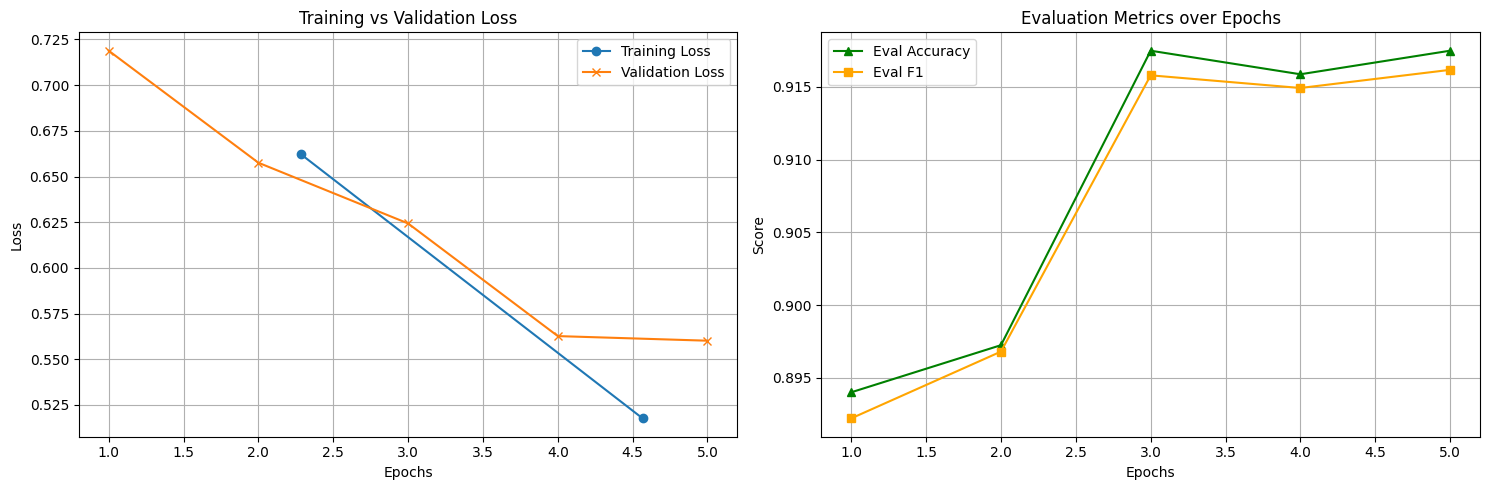

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df_history = pd.DataFrame(trainer_final.state.log_history)

train_df_hist = df_history[df_history['loss'].notna()].groupby('epoch')['loss'].mean().reset_index()
eval_df_hist = df_history[df_history['eval_loss'].notna()]

plt.figure(figsize=(15, 5))

# Left: Loss
plt.subplot(1, 2, 1)
plt.plot(train_df_hist['epoch'], train_df_hist['loss'], label='Training Loss', marker='o')
plt.plot(eval_df_hist['epoch'], eval_df_hist['eval_loss'], label='Validation Loss', marker='x')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Right: Accuracy
plt.subplot(1, 2, 2)
plt.plot(eval_df_hist['epoch'], eval_df_hist['eval_accuracy'], label='Eval Accuracy', color='green', marker='^')
plt.plot(eval_df_hist['epoch'], eval_df_hist['eval_f1'], label='Eval F1', color='orange', marker='s')
plt.title('Evaluation Metrics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dự đoán trên tập test
test_results = trainer_final.predict(test_dataset)
y_pred = np.argmax(test_results.predictions, axis=-1)
y_test = test_results.label_ids

print(classification_report(y_test, y_pred, target_names=['CLEAN', 'OFFENSIVE', 'HATE']))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

       CLEAN       0.93      0.96      0.94       563
   OFFENSIVE       0.88      0.89      0.88       169
        HATE       0.92      0.81      0.86       184

    accuracy                           0.92       916
   macro avg       0.91      0.89      0.90       916
weighted avg       0.92      0.92      0.92       916



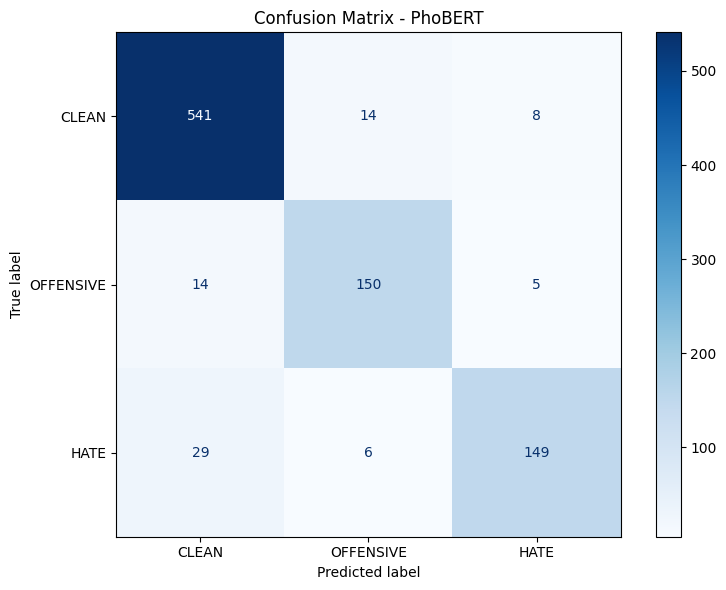

In [38]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['CLEAN', 'OFFENSIVE', 'HATE']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Confusion Matrix - PhoBERT')
plt.tight_layout()
plt.show()
